**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

EQUIPO 28   
INTEGRANTES :
*   TERESA DE JESUS MORENO MARTINEZ -A01840597
*   FRIDA ALEJANDRA MOYAO LEÓN - A01026354
*   ANA CRISTINA MUNGUÍA ROMERO - A01740019
*   MARCO ANTONIO MUÑOZ CHAVEZ - A01686968

In [1]:
import pandas as pd
df = pd.read_csv("insurance.csv")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
insurance_df = pd.read_csv('insurance.csv')
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Parte 1**. EDA

Efectúa una exploración inicial de los datos a través de:

1a) Estadísticas descriptivas para todas las variables del dataframe.

In [5]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


1b) Búsqueda de valores faltantes.

In [6]:
# Buscar valores faltantes
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


1c) Histrogramas y boxplots para las variables cuantitativas y diagramas de barras con la frecuencia para las variables categóricas.

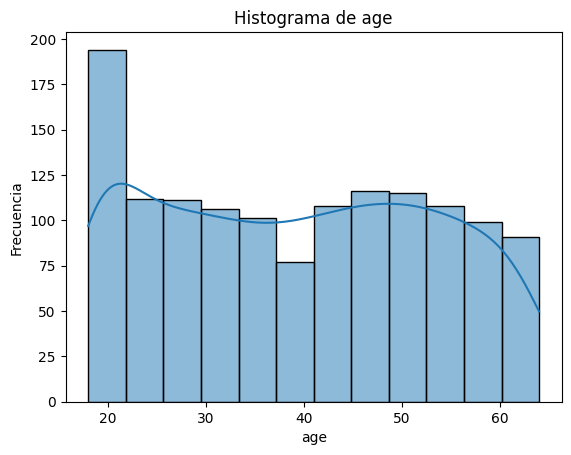

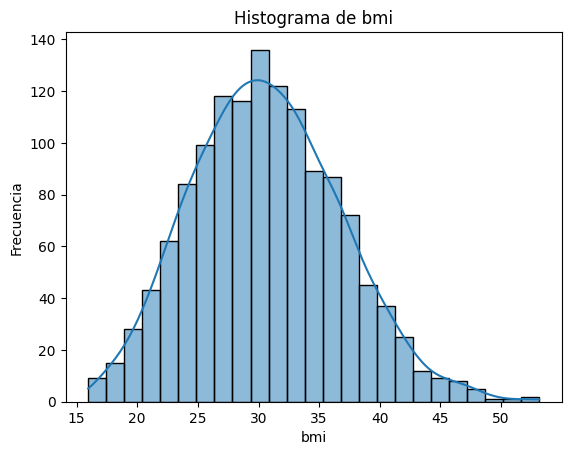

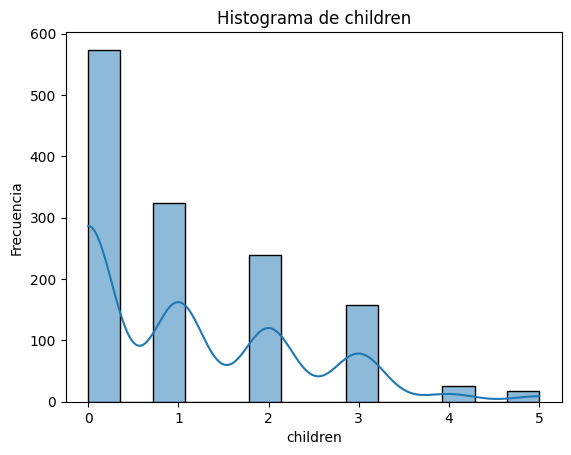

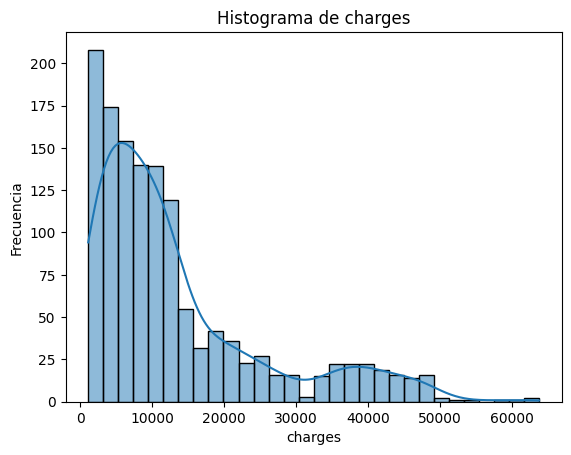

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

numericas = ['age', 'bmi', 'children', 'charges']

for col in numericas:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

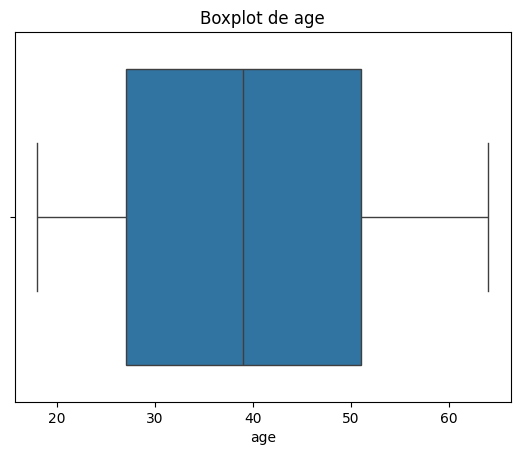

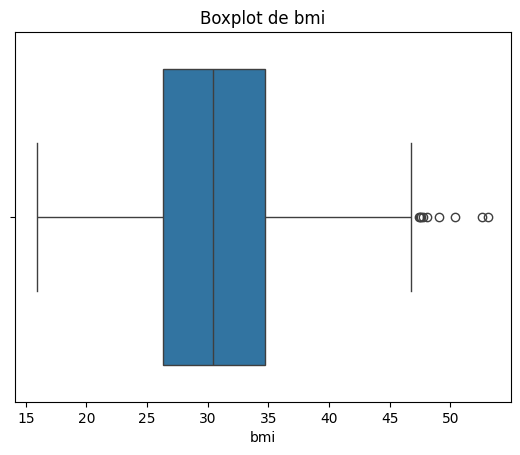

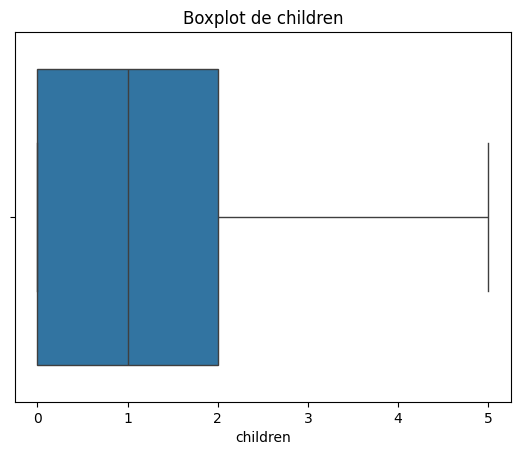

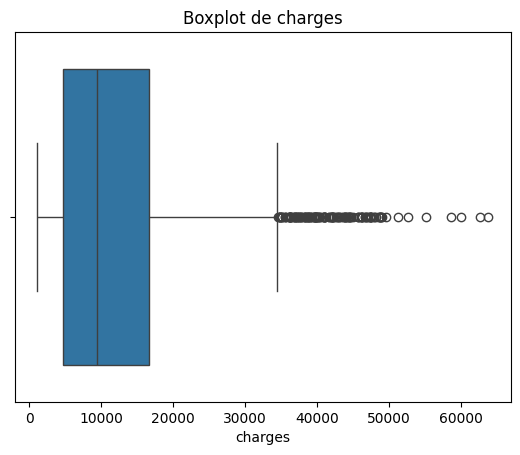

In [8]:
for col in numericas:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()

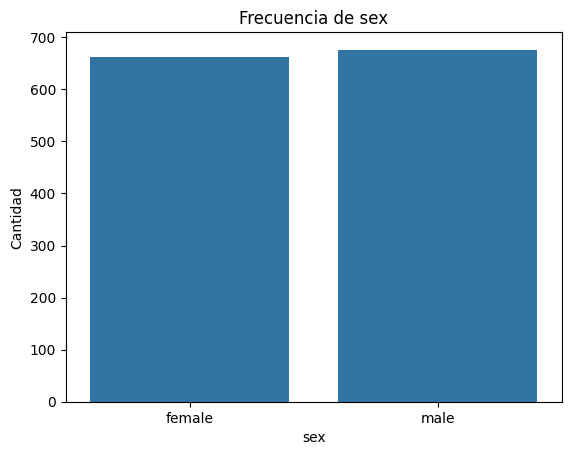

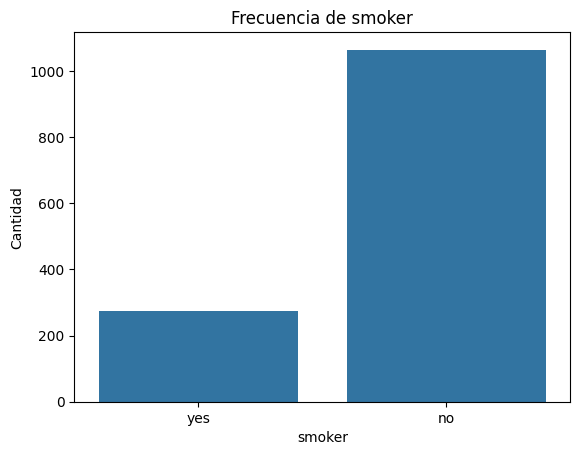

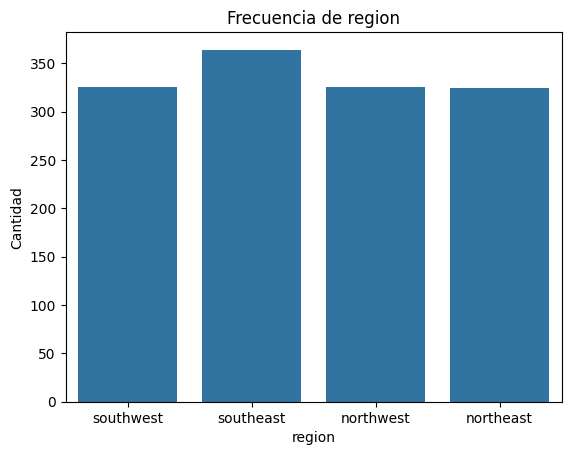

In [9]:
categoricas = ['sex', 'smoker', 'region']

for col in categoricas:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f'Frecuencia de {col}')
    plt.xlabel(col)
    plt.ylabel('Cantidad')
    plt.show()

Para responder los siguientes cuestionamientos, genera los gráficos indicados:

2a) ¿Hay diferencias significativas de las primas según el sexo? Compara la distribución de la variable `charges` por medio de un boxplot.

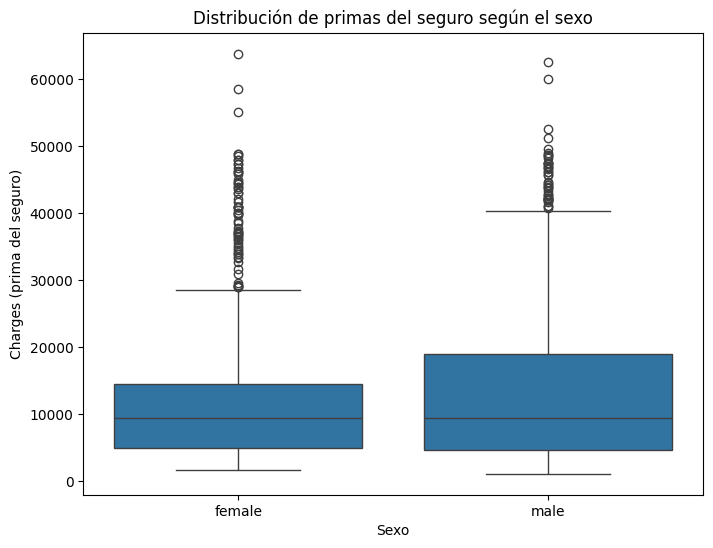

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='sex', y='charges', data=df)

plt.title('Distribución de primas del seguro según el sexo')
plt.xlabel('Sexo')
plt.ylabel('Charges (prima del seguro)')

plt.show()

Para analizar si existen diferencias en las primas del seguro según el sexo, se generó un boxplot de la variable charges agrupada por sex.

A partir del gráfico se observa que las medianas de las primas para hombres y mujeres son muy similares, ubicándose aproximadamente alrededor de los 9,000–10,000. Sin embargo, el grupo de hombres presenta una mayor dispersión, ya que el rango intercuartílico y los valores máximos son ligeramente más altos en comparación con las mujeres.

Además, se identifican varios valores atípicos (outliers) en ambos grupos, lo que indica que algunos asegurados tienen primas significativamente más altas que la mayoría.

En general, aunque los hombres muestran una variabilidad ligeramente mayor en los costos, no se observan diferencias significativamente marcadas en las primas del seguro basadas únicamente en el sexo.

2b) Crea un diagrama de dispersión de `charges` versus el `bmi` que incorpore la distinción por las categorías `smoker` y `children` (tip: utiliza el parámetro `size`) ¿Hay alguna conclusión importante que se derive del gráfico?

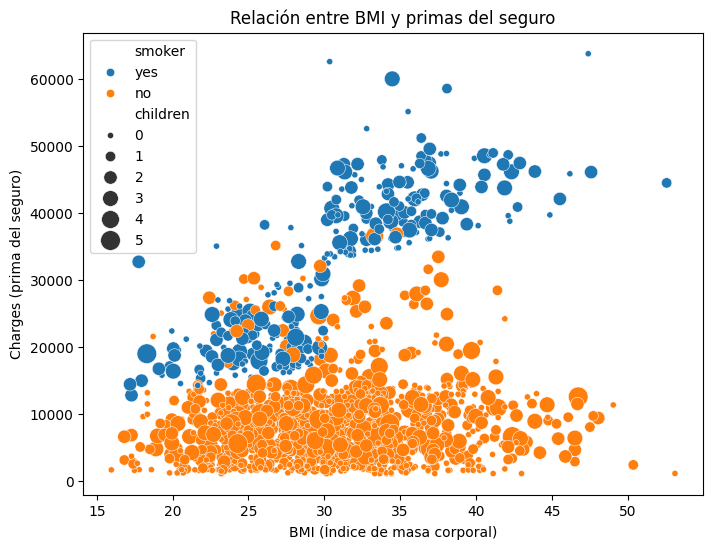

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='bmi',
    y='charges',
    hue='smoker',      # diferencia fumadores
    size='children',   # tamaño según número de hijos
    data=df,
    sizes=(20,200)
)

plt.title('Relación entre BMI y primas del seguro')
plt.xlabel('BMI (Índice de masa corporal)')
plt.ylabel('Charges (prima del seguro)')

plt.show()

Se generó un diagrama de dispersión entre BMI y charges, diferenciando a los asegurados según si son fumadores o no mediante colores y representando el número de hijos a través del tamaño de los puntos.

A partir del gráfico se observa una conclusión muy clara: los fumadores tienen primas de seguro significativamente más altas que los no fumadores. Los puntos correspondientes a fumadores se concentran en valores de charges mucho más elevados, alcanzando incluso valores superiores a 60,000, mientras que los no fumadores generalmente se mantienen por debajo de 20,000.

También se aprecia que entre los fumadores existe una relación positiva entre BMI y charges, es decir, a mayor índice de masa corporal, mayor tiende a ser el costo del seguro.

En cuanto al número de hijos, representado por el tamaño de los puntos, no se observa una relación clara con el costo de la prima.

En conclusión, el gráfico sugiere que ser fumador es uno de los factores más determinantes en el aumento del costo del seguro, especialmente cuando se combina con valores altos de BMI.

2c) Elabora un mapa de calor que muestre la correlación de las variables numéricas.

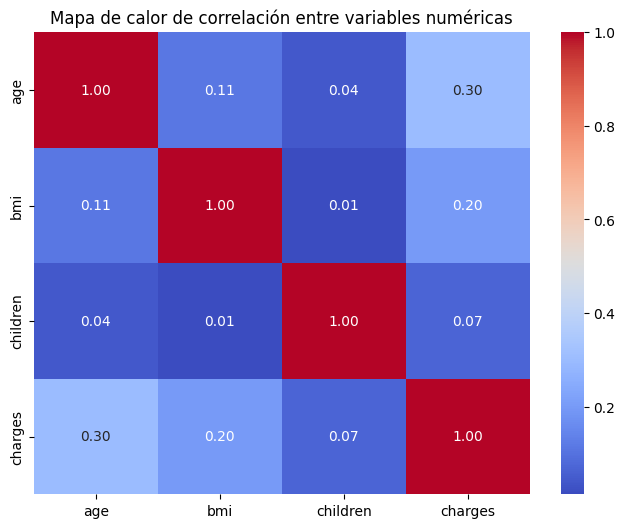

In [12]:
plt.figure(figsize=(8,6))

# calcular matriz de correlación
corr = df[['age','bmi','children','charges']].corr()

# heatmap
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title('Mapa de calor de correlación entre variables numéricas')

plt.show()

Obtén un dataframe con las observaciones que tengan valores atípicos en `charges`.

3a) ¿Cuál es el promedio de `age` y de `bmi` en el dataframe de valores atípicos obtenido?

In [13]:

# Calcular cuartiles para 'charges'
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

# Calcular el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# Definir los límites para detectar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Obtener el dataframe con los valores atípicos en 'charges'
outliers_df = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]

print("Valores atípicos en 'charges' (primeras 5 filas):")
display(outliers_df.head())

# Calcular el promedio de 'age' y 'bmi' en el dataframe de outliers
average_age_outliers = outliers_df['age'].mean()
average_bmi_outliers = outliers_df['bmi'].mean()

print(f"\nPromedio de 'age' en los outliers: {average_age_outliers:.2f}")
print(f"Promedio de 'bmi' en los outliers: {average_bmi_outliers:.2f}")

Valores atípicos en 'charges' (primeras 5 filas):


,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760



Promedio de 'age' en los outliers: 41.08
Promedio de 'bmi' en los outliers: 35.56


3b) ¿Qué porcentaje de estas observaciones (en el dataframe de valores atípicos obtenidos) se corresponden a mujeres y a hombres? ¿A fumadores y no fumadores?

In [14]:
# Porcentaje de mujeres y hombres en el dataframe de outliers
sex_distribution_outliers = outliers_df['sex'].value_counts(normalize=True) * 100
print("\nDistribución de 'sex' en los outliers:")
display(sex_distribution_outliers)

# Porcentaje de fumadores y no fumadores en el dataframe de outliers
smoker_distribution_outliers = outliers_df['smoker'].value_counts(normalize=True) * 100
print("\nDistribución de 'smoker' en los outliers:")
display(smoker_distribution_outliers)


Distribución de 'sex' en los outliers:


,proportion
sex,
male,64.028777
female,35.971223



Distribución de 'smoker' en los outliers:


,proportion
smoker,
yes,97.841727
no,2.158273


# **Parte 2**. Preprocesamiento

4. Separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`charges`).

In [15]:
# Calcular cuartiles
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

# Rango intercuartílico
IQR = Q3 - Q1

# Límites para detectar outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Dataframe con valores atípicos
outliers = df[(df['charges'] < lower) | (df['charges'] > upper)]

outliers.head()

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768
29,31,male,36.30,2,yes,southwest,38711.0000
30,22,male,35.60,0,yes,southwest,35585.5760


In [16]:
outliers[['age','bmi']].mean()

,0
age,41.079137
bmi,35.564604


Para responder esta pregunta, primero se identificaron los valores atípicos de la variable charges utilizando el método del rango intercuartílico (IQR). Posteriormente se creó un dataframe que contiene únicamente las observaciones con valores atípicos en dicha variable.

A partir de este dataframe se calcularon los promedios de las variables age y bmi.

Los resultados obtenidos fueron:

Promedio de edad (age): 41.08 años

Promedio de índice de masa corporal (bmi): 35.56

Estos resultados indican que las personas con costos de seguro extremadamente altos tienden a tener una edad promedio superior a los 40 años y un BMI elevado, cercano al rango de obesidad. Esto sugiere que factores como mayor edad y mayor índice de masa corporal pueden estar asociados con primas de seguro más altas.

5. Divide el conjunto en entrenamiento y prueba (80:20) considerando:


*   El parámetro `random_state` con el valor de 1 para garantizar reproducibilidad.
*   Analiza los diagramas de barras obtenidos en el ejercicio 1c. Con los resultados observados, es conveniente usar la variable `smoker` en la estrategia de estratificación.
*   Como ya tienes separadas en `X` e `y` los predictores y salida, consulta cómo ejecutar la función `train_test_split()` para obtener `Xtrain, Xtest, ytrain, ytest` en una única instrucción.

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop('charges', axis=1)
y = df['charges']

In [19]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=df['smoker']
)

El conjunto de datos se dividió en conjunto de entrenamiento (80%) y conjunto de prueba (20%) utilizando la función train_test_split() de la librería scikit-learn.

Para garantizar la reproducibilidad de los resultados, se utilizó el parámetro random_state=1.

Además, considerando los resultados observados en los diagramas de barras del ejercicio 1c, se decidió utilizar la variable smoker como criterio de estratificación, ya que esta variable tiene una fuerte relación con el costo del seguro. Esto permite mantener una proporción similar de fumadores y no fumadores tanto en el conjunto de entrenamiento como en el de prueba.

De esta manera se obtuvieron los conjuntos Xtrain, Xtest, ytrain y ytest, que serán utilizados para entrenar y evaluar el modelo de regresión.

test_size = 0.2 → 20% para prueba, 80% entrenamiento

random_state = 1 → asegura que siempre se obtenga la misma división

stratify = df['smoker'] → mantiene la misma proporción de fumadores y no fumadores en train y test

6. Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento *MinMax* a los predictores numéricos y codificación *one-hot* a los categóricas.

In [20]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [21]:
numericas = ['age','bmi','children']
categoricas = ['sex','smoker','region']

In [22]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numericas),
        ('cat', OneHotEncoder(), categoricas)
    ]
)

Se construyó un transformador llamado preprocessing utilizando ColumnTransformer. Este transformador aplica escalamiento MinMax a las variables numéricas (age, bmi y children) con el fin de normalizar sus valores en un rango entre 0 y 1.

Para las variables categóricas (sex, smoker y region) se utilizó codificación one-hot mediante OneHotEncoder, lo que permite convertir las categorías en variables binarias que pueden ser utilizadas por el modelo de regresión.

# **Parte 3**. Entrenando y evaluando el modelo de RL

7. Ejecuta un pipeline con el transformador creado y el algoritmo de regresión lineal para entrenar un modelo denominado `lr_model`.

Evalúa el modelo en el conjunto de prueba y obtén la raíz del error cuadrático medio (`RMSE`) y la métrica `R` cuadrado ($R^2$). Aunque ésta última la estudiarás a detalle la próxima semana, ahora sólo debes saber que toma valores entre 0 y 1, donde 1 indica un ajuste perfecto y, por tanto, un modelo muy fiable para las previsiones futuras. La función de scikit-learn que determina esta métrica es: [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [23]:
#Importar librerías necesarias
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [24]:
#Crear el pipeline con el preprocesamiento y el modelo
lr_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LinearRegression())
])

In [25]:
#Entrenar modelo
lr_model.fit(Xtrain, ytrain)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [26]:
#Hacer predicciones con el conjunto de prueba
y_pred = lr_model.predict(Xtest)

In [27]:
#Calcular las métricas del modelo
rmse = np.sqrt(mean_squared_error(ytest, y_pred))
rmse

np.float64(5698.759784532354)

In [28]:
r2 = r2_score(ytest, y_pred)
r2

0.7538547215244327

Se construyó un pipeline que integra el transformador de preprocesamiento y el algoritmo de regresión lineal. El pipeline aplica primero el escalamiento MinMax a las variables numéricas y la codificación one-hot a las variables categóricas, y posteriormente entrena el modelo de regresión lineal.

El modelo fue entrenado utilizando el conjunto de entrenamiento y posteriormente evaluado en el conjunto de prueba.

Para evaluar el desempeño del modelo se calcularon las siguientes métricas:

RMSE (Root Mean Squared Error): 5698.76

R² (coeficiente de determinación): 0.754

El RMSE indica que, en promedio, las predicciones del modelo tienen un error aproximado de 5699 unidades monetarias respecto al valor real de las primas del seguro.

Por otro lado, el R² = 0.754 indica que el modelo es capaz de explicar aproximadamente el 75.4% de la variabilidad en el costo de las primas del seguro, lo cual representa un buen nivel de ajuste, aunque todavía existe una parte de la variabilidad que no es explicada por el modelo.

**Valora el rendimiento del modelo con los siguientes cambios:**


8. Reemplaza los outliers de `charges` con el límite superior (`Q3 + 1.5 * IQR`). Haz el cambio en ambos conjuntos: `ytrain` y `ytest`, previo a la aplicación del mismo pipeline. Guarda el modelo como `lr_model2`.


In [29]:
#Calcular el límite superior de outliers, usamos Q3 + 1.5 * IQR
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
upper_limit

np.float64(34489.350562499996)

In [30]:
#Reemplazar los outliers en ytrain y ytest, usamos clip() para limitar los valores máximos
ytrain_capped = ytrain.clip(upper=upper_limit)
ytest_capped = ytest.clip(upper=upper_limit)

In [31]:
#Se crea nuevamente el pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model2 = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LinearRegression())
])

In [32]:
#entrena nuevo modelo
lr_model2.fit(Xtrain, ytrain_capped)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat', OneHotEncoder(),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [33]:
#predicciones
y_pred2 = lr_model2.predict(Xtest)

In [34]:
#evaluar nuevo modelo
rmse2 = np.sqrt(mean_squared_error(ytest_capped, y_pred2))
r2_2 = r2_score(ytest_capped, y_pred2)

rmse2
r2_2

0.7637776364359083

Para evaluar el impacto de los valores atípicos en el modelo, se reemplazaron los valores extremos de la variable charges utilizando el límite superior definido por el método del rango intercuartílico (Q3 + 1.5 × IQR). Este ajuste se aplicó tanto al conjunto de entrenamiento como al conjunto de prueba.

Posteriormente se entrenó un nuevo modelo de regresión lineal utilizando el mismo pipeline de preprocesamiento, guardándolo como lr_model2.

Al evaluar el nuevo modelo se obtuvo:

R² = 0.7638

Este valor es ligeramente mayor que el obtenido con el modelo original (R² = 0.7539), lo que indica que el nuevo modelo explica una mayor proporción de la variabilidad de las primas del seguro.

Esto sugiere que reemplazar los valores atípicos mejora ligeramente el desempeño del modelo, ya que reduce el impacto de valores extremos que pueden afectar el ajuste de la regresión lineal.

En conclusión, el modelo lr_model2 presenta un mejor rendimiento que el modelo original, mostrando una capacidad ligeramente superior para predecir el costo de las primas del seguro.

9. Prepara otro transformador, denominado `preprocessing2`, para aplicar escalamiento estándar a los predictores numéricos y codificación ordinal a los categóricas. Aplícalo en un nuevo pipeline utilizando nuevamente regresión lineal. Guarda el modelo como `lr_model3`.

**Nota.** Los cambios se ejecutan de manera consecutiva, por ejemplo: el reemplazo de los outliers también se ejecuta previo al transformador `preprocessing2` y así sucesivamente.

In [35]:
# Importaciones necesarias
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Definir las columnas numéricas y categóricas
numericas = ['age', 'bmi', 'children']
categoricas = ['sex', 'smoker', 'region']

# Crear el transformador preprocessing2
preprocessing2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numericas),
        ('cat', OrdinalEncoder(), categoricas)
    ])

# Construir el pipeline con preprocessing2 y regresión lineal
lr_model3 = Pipeline([
    ('preprocessing', preprocessing2),
    ('model', LinearRegression())
])

# Entrenar el modelo
lr_model3.fit(Xtrain, ytrain_capped)

# Predecir y evaluar
y_pred3 = lr_model3.predict(Xtest)
rmse3 = np.sqrt(mean_squared_error(ytest_capped, y_pred3))
r2_3 = r2_score(ytest_capped, y_pred3)

# Mostrar resultados
print(f"RMSE (lr_model3): {rmse3:.4f}")
print(f"R²   (lr_model3): {r2_3:.4f}")

RMSE (lr_model3): 4811.6007
R²   (lr_model3): 0.7638


10. Utiliza regresión polinomial para verificar si se produce un mejor ajuste. Intenta con varios grados, aunque debes dejar en el código sólo el de mejor rendimiento. Guarda el modelo como `lr_model4`.

In [36]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Mejor grado encontrado tras probar varios
mejor_grado = 2

# Crear pipeline con preprocesamiento,
# características polinomiales y regresión lineal
lr_model4 = Pipeline([
    ('preprocessing', preprocessing2),
    ('poly', PolynomialFeatures(degree=mejor_grado, include_bias=False)),
    ('regresion', LinearRegression())
])

# Entrenar el modelo
lr_model4.fit(Xtrain, ytrain_capped)

# Predecir y evaluar sobre el conjunto de prueba
y_pred4 = lr_model4.predict(Xtest)
rmse4 = np.sqrt(mean_squared_error(ytest_capped, y_pred4))
r2_4 = r2_score(ytest_capped, y_pred4)

# Mostrar resultados
print(f"Grado utilizado: {mejor_grado}")
print(f"RMSE (lr_model4): {rmse4:.4f}")
print(f"R²   (lr_model4): {r2_4:.4f}")

Grado utilizado: 2
RMSE (lr_model4): 4285.5703
R²   (lr_model4): 0.8126
